In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Loading required dataset
Swiggy = pd.read_csv('swiggy.csv')

In [3]:
Swiggy.shape

(8680, 10)

In [4]:
Swiggy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8680 entries, 0 to 8679
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             8680 non-null   int64  
 1   Area           8680 non-null   object 
 2   City           8680 non-null   object 
 3   Restaurant     8680 non-null   object 
 4   Price          8676 non-null   float64
 5   Avg_ratings    8680 non-null   float64
 6   Total_ratings  8680 non-null   int64  
 7   Food_type      8680 non-null   object 
 8   Address        8680 non-null   object 
 9   Delivery_time  8680 non-null   int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 678.3+ KB


In [5]:
Swiggy.describe()

,ID,Price,Avg_ratings,Total_ratings,Delivery_time
count,8680.000000,8676.000000,8680.000000,8680.000000,8680.000000
mean,244812.071429,348.456432,3.655104,156.634793,53.967051
std,158671.617188,230.989376,0.647629,391.448014,14.292335
min,211.000000,0.000000,2.000000,20.000000,20.000000
25%,72664.000000,200.000000,2.900000,50.000000,44.000000
50%,283442.000000,300.000000,3.900000,80.000000,53.000000
75%,393425.250000,400.000000,4.200000,100.000000,64.000000
max,466928.000000,2500.000000,5.000000,10000.000000,109.000000


In [6]:
Swiggy

,ID,Area,City,Restaurant,Price,Avg_ratings,Total_ratings,Food_type,Address,Delivery_time
0,211,Koramangala,Bangalore,Tandoor Hut,300.0,4.4,100,"Biryani,Chinese,North Indian,South Indian",5Th Block,59
1,221,Koramangala,Bangalore,Tunday Kababi,300.0,4.1,100,"Mughlai,Lucknowi",5Th Block,56
2,246,Jogupalya,Bangalore,Kim Lee,650.0,4.4,100,Chinese,Double Road,50
3,248,Indiranagar,Bangalore,New Punjabi Hotel,250.0,3.9,500,"North Indian,Punjabi,Tandoor,Chinese",80 Feet Road,57
4,249,Indiranagar,Bangalore,Nh8,350.0,4.0,50,"Rajasthani,Gujarati,North Indian,Snacks,Desser...",80 Feet Road,63
...,...,...,...,...,...,...,...,...,...,...
8675,464626,Panjarapole Cross Road,Ahmedabad,Malt Pizza,500.0,2.9,80,Pizzas,Navrangpura,40
8676,465835,Rohini,Delhi,Jay Mata Ji Home Kitchen,200.0,2.9,80,South Indian,Rohini,28
8677,465872,Rohini,Delhi,Chinese Kitchen King,150.0,2.9,80,"Chinese,Snacks,Tandoor",Rohini,58
8678,465990,Rohini,Delhi,Shree Ram Paratha Wala,150.0,2.9,80,"North Indian,Indian,Snacks",Rohini,28


In [7]:
Swiggy.nunique()

ID               8680
Area              833
City                9
Restaurant       7865
Price             119
Avg_ratings        30
Total_ratings       8
Food_type        3734
Address          2339
Delivery_time      81
dtype: int64

In [8]:
mode_area = Swiggy['Area'].mode()[0]

In [9]:
mode_area

'Rohini'

In [10]:
Area_counts = Swiggy['Area'].value_counts().reset_index()

In [11]:
Area_counts

,Area,count
0,Rohini,257
1,Chembur,208
2,Kothrud,149
3,Andheri East,135
4,Navrangpura,132
...,...,...
828,Shakurpur,1
829,Magob,1
830,Bosepukur,1
831,Ambegaon,1


In [12]:
Area_counts.columns = ['Area', 'Area_Count']  # Rename for clarity

In [13]:
Area_counts.groupby('Area_Count')['Area'].apply(list).reset_index(name = 'Areas')
#Area_counts.groupby('Area_Count')['Area'].apply(list)

,Area_Count,Areas
0,1,"[Ra Puram, Chembur Colony, The New Sion Co-Ope..."
1,2,"[Gidc Naroda, Hirabaugh, Sector 15 Rohini, Nag..."
2,3,"[Manicktala, Sayedpura, Majura Gate, Dahin Nag..."
3,4,"[Vikhroli West, Adarsh Nagar, Nava Vadaj, Kond..."
4,5,"[Narolgam, Adajan Patiya, Srirampura, Magarpat..."
...,...,...
75,132,[Navrangpura]
76,135,[Andheri East]
77,149,[Kothrud]
78,208,[Chembur]


In [14]:
area_frequency = Area_counts.groupby('Area_Count').size().reset_index(name='Number_of_Areas')

In [15]:
area_frequency

,Area_Count,Number_of_Areas
0,1,330
1,2,96
2,3,52
3,4,51
4,5,32
...,...,...
75,132,1
76,135,1
77,149,1
78,208,1


In [16]:
area_frequency.tail(20)

,Area_Count,Number_of_Areas
60,73,2
61,74,2
62,75,1
63,89,1
64,91,1
65,92,1
66,94,1
67,99,1
68,110,1
69,113,1


In [17]:
Swiggy

,ID,Area,City,Restaurant,Price,Avg_ratings,Total_ratings,Food_type,Address,Delivery_time
0,211,Koramangala,Bangalore,Tandoor Hut,300.0,4.4,100,"Biryani,Chinese,North Indian,South Indian",5Th Block,59
1,221,Koramangala,Bangalore,Tunday Kababi,300.0,4.1,100,"Mughlai,Lucknowi",5Th Block,56
2,246,Jogupalya,Bangalore,Kim Lee,650.0,4.4,100,Chinese,Double Road,50
3,248,Indiranagar,Bangalore,New Punjabi Hotel,250.0,3.9,500,"North Indian,Punjabi,Tandoor,Chinese",80 Feet Road,57
4,249,Indiranagar,Bangalore,Nh8,350.0,4.0,50,"Rajasthani,Gujarati,North Indian,Snacks,Desser...",80 Feet Road,63
...,...,...,...,...,...,...,...,...,...,...
8675,464626,Panjarapole Cross Road,Ahmedabad,Malt Pizza,500.0,2.9,80,Pizzas,Navrangpura,40
8676,465835,Rohini,Delhi,Jay Mata Ji Home Kitchen,200.0,2.9,80,South Indian,Rohini,28
8677,465872,Rohini,Delhi,Chinese Kitchen King,150.0,2.9,80,"Chinese,Snacks,Tandoor",Rohini,58
8678,465990,Rohini,Delhi,Shree Ram Paratha Wala,150.0,2.9,80,"North Indian,Indian,Snacks",Rohini,28


In [52]:
Swiggy['City'].value_counts().sort_values(ascending = False).reindex

<bound method Series.reindex of City
Kolkata      1346
Mumbai       1277
Chennai      1106
Pune         1090
Hyderabad    1075
Bangalore     946
Ahmedabad     717
Delhi         611
Surat         512
Name: count, dtype: int64>

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Bangalore'),
  Text(1, 0, 'Hyderabad'),
  Text(2, 0, 'Mumbai'),
  Text(3, 0, 'Pune'),
  Text(4, 0, 'Kolkata'),
  Text(5, 0, 'Delhi'),
  Text(6, 0, 'Chennai'),
  Text(7, 0, 'Ahmedabad'),
  Text(8, 0, 'Surat')])

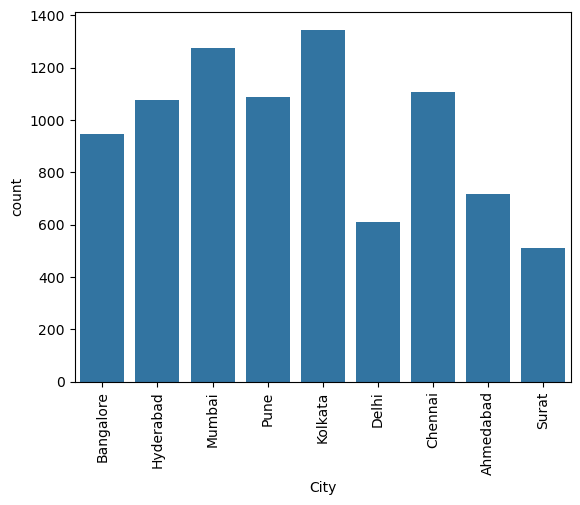

In [53]:
sns.countplot(x = 'City', data = Swiggy)
plt.xticks(rotation = 90)

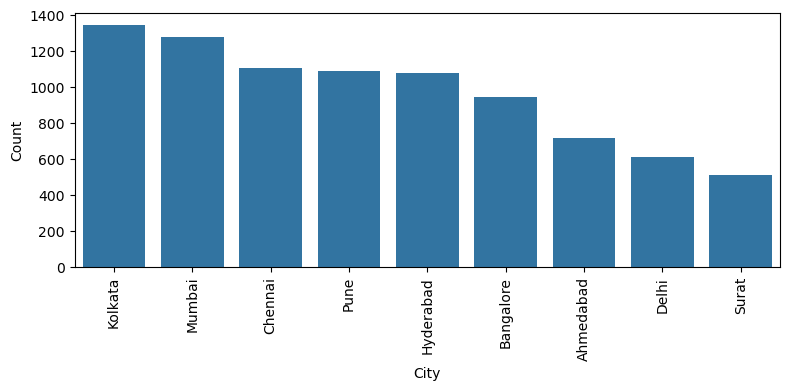

In [20]:
# Step 1: Get city counts in ascending order
city_order = Swiggy['City'].value_counts(ascending=False).index

# Step 2: Plot
plt.figure(figsize=(8, 4))
sns.countplot(x='City', data=Swiggy, order=city_order)
plt.xticks(rotation=90)
plt.title = 'Number of Restaurants per City'
plt.ylabel('Count')
plt.xlabel('City')
plt.tight_layout()
plt.show()


### Maximum number of restaurants is in Kolkata followed by Mumbai

In [21]:
Reataurant_count = Swiggy['Restaurant'].value_counts()

In [22]:
top_10_Rest = Reataurant_count.head(10)

In [23]:
top_10_Rest

Restaurant
La Pino'Z Pizza                        13
Nic Natural Ice Creams                 10
Baskin Robbins                         10
Subway                                 10
Kfc                                     9
Keventers - Milkshakes And Desserts     9
Oven Story Pizza                        9
Natural Ice Cream                       9
Pizza Hut                               9
Behrouz Biryani                         9
Name: count, dtype: int64

#### Top 10 restaurants having highest rating

In [24]:
top_10_restaurants = Swiggy.groupby('Restaurant')['Avg_ratings'].mean().sort_values(ascending = False).head(10)

In [25]:
top_10_restaurants

Restaurant
Diamond Market Pizza Jp                 5.0
Get In My Belly                         5.0
Splurge - Thickshakes And Milkshakes    5.0
Snaxx                                   5.0
Nivala Apka Apna                        5.0
The Asian Pavilion                      5.0
Shree Krishna Juice Bar                 5.0
Tricky Shakes                           5.0
The Liege Waffles                       5.0
Wallonia Waffle Co.                     5.0
Name: Avg_ratings, dtype: float64

#### Bottom 10 restaurants having lowest rating

In [26]:
Swiggy.groupby('Restaurant')['Avg_ratings'].mean().sort_values(ascending = False).tail(10)

Restaurant
Maggi Bowl                      2.7
Jannath Chicken                 2.7
Urban Foods Ambawadi            2.6
Down Town House                 2.6
Cia Chinese In Ahmedabad        2.4
Diwan Food Court                2.3
Frosty Den                      2.2
The Shawarma Daddy              2.2
Hyderabadi Biryani House        2.2
Golden Dragon Chinese & Momo    2.0
Name: Avg_ratings, dtype: float64

Text(0, 0.5, 'Count of Avg ratings')

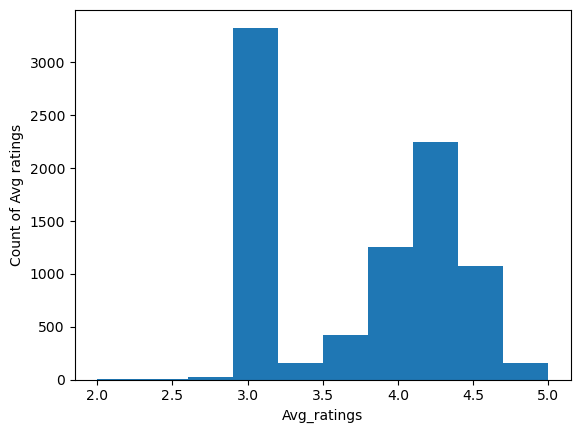

In [27]:
plt.hist(Swiggy.Avg_ratings, bins=10)
plt.xlabel('Avg_ratings')
plt.ylabel('Count of Avg ratings')

#### Top 10 Areas having highest rating

In [28]:
Swiggy.groupby('Area')['Avg_ratings'].mean().sort_values(ascending = False).head(10)

Area
Girish Park              4.9
Vardhman Premium Mall    4.8
Ekdalia                  4.7
Santacruz Bandra East    4.7
Wallace Garden           4.7
Mogapair                 4.7
Matunga East             4.7
Beltala Road             4.7
Ra Puram                 4.6
Bandra Kurla Complex     4.6
Name: Avg_ratings, dtype: float64

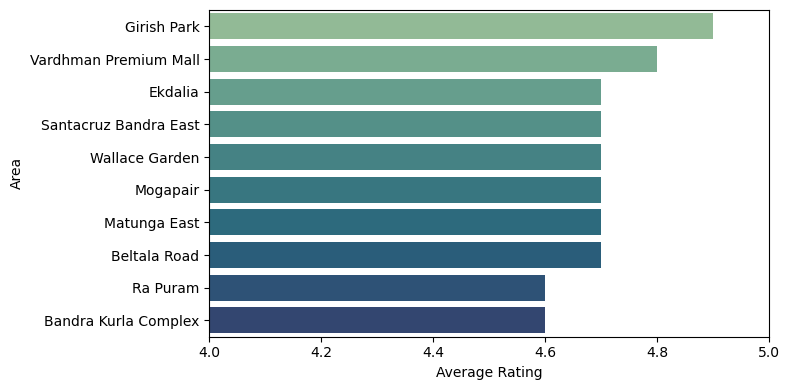

In [54]:
# Get top 10 areas by average rating
top_areas = Swiggy.groupby('Area')['Avg_ratings'].mean().sort_values(ascending=False).head(10).reset_index()

# Bar plot with Area as y-axis
plt.figure(figsize=(8, 4))
sns.barplot(x='Avg_ratings', y='Area', data=top_areas, hue='Area', palette='crest', legend=False)

# Add axis labels and title
plt.xlabel("Average Rating")
plt.ylabel("Area")
#plt.title("Top 10 Areas by Average Rating")
plt.xlim(4, 5)
plt.tight_layout()
plt.show()

#### Bottom 10 Areas having lowest rating

In [30]:
Swiggy.groupby('Area')['Avg_ratings'].mean().sort_values(ascending = False).tail(10)

Area
Sagrampuraathwa             2.9
Dum Dum Park                2.9
Dindoli                     2.9
Sainik Vihar Pritampura     2.9
Saki Naka   Andheri East    2.9
Dhanakawadi                 2.9
Dapodi                      2.9
Shakurpur                   2.8
Punjab Bagh                 2.7
Kausar Baugh Nibm Road      2.2
Name: Avg_ratings, dtype: float64

TypeError: 'str' object is not callable

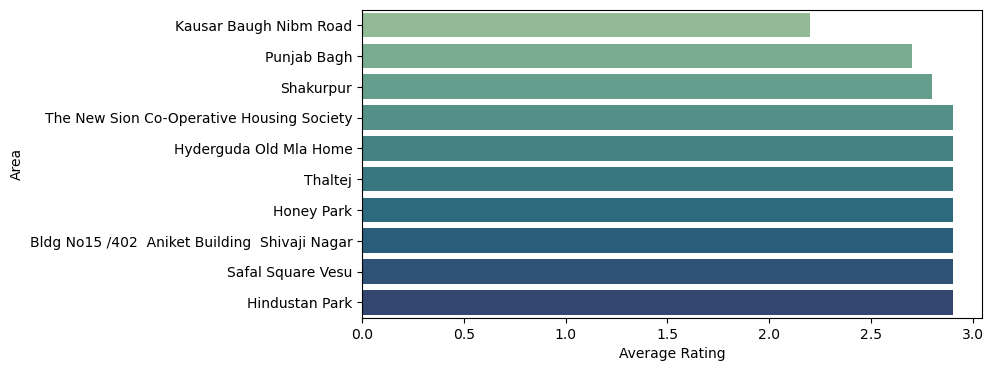

In [55]:
# Step 1: Get bottom 10 areas by average rating
bottom_areas = Swiggy.groupby('Area')['Avg_ratings'].mean().sort_values(ascending=True).head(10).reset_index()

# Step 2: Bar plot
plt.figure(figsize=(8, 4))
sns.barplot(x='Avg_ratings', y='Area', data=bottom_areas, hue='Area', palette='crest', legend=False)

# Step 3: Labels and layout
plt.xlabel("Average Rating")
plt.ylabel("Area")
plt.title("Bottom 10 Areas by Average Rating")
plt.xlim(3, 5)
plt.tight_layout()
plt.show()

In [32]:
Swiggy['Price'].mode()[0]

300.0

In [33]:
Price_top10 = Swiggy['Price'].value_counts().nlargest(10).index
#Price_top10 = Swiggy['Price'].value_counts().nlargest(10)
Swiggy_ = Swiggy[Swiggy['Price'].isin(Price_top10)]

In [34]:
Price_top10

Index([300.0, 200.0, 250.0, 400.0, 500.0, 150.0, 350.0, 100.0, 600.0, 450.0], dtype='float64', name='Price')

<Axes: xlabel='Price', ylabel='count'>

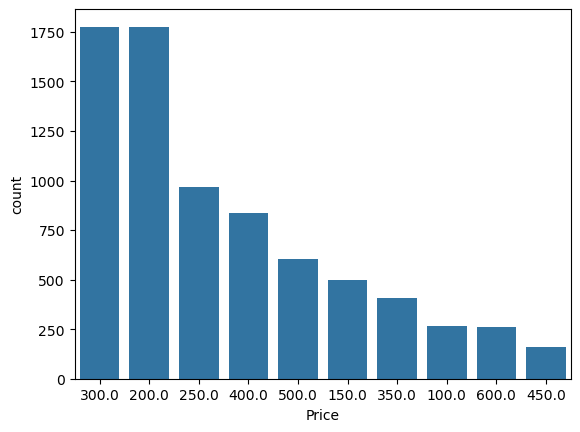

In [36]:
sns.countplot(x = 'Price', data = Swiggy_, order = Price_top10)

#### Most frequent ordered prices are 300 and 200.

In [38]:
Food_type_top10 = Swiggy['Food_type'].value_counts().nlargest(10).index
#Price_top10 = Swiggy['Price'].value_counts().nlargest(10)
Swiggy_ = Swiggy[Swiggy['Food_type'].isin(Food_type_top10)]

In [39]:
Food_type_top10

Index(['Indian', 'Chinese', 'North Indian', 'Fast Food', 'South Indian',
       'Indian,Chinese', 'Desserts', 'North Indian,Chinese', 'Bakery',
       'Beverages'],
      dtype='object', name='Food_type')

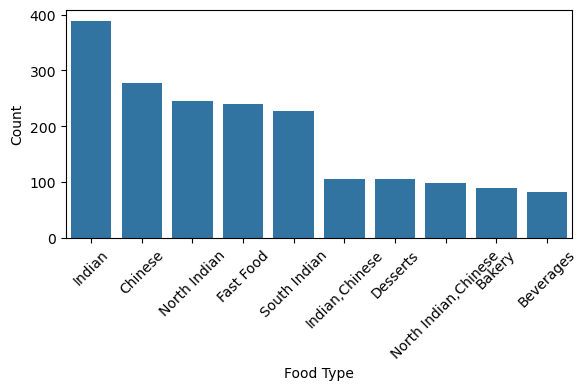

In [61]:
plt.figure(figsize=(6, 4))  # Smaller size; adjust as needed
sns.countplot(x='Food_type', data=Swiggy_, order=Food_type_top10)
plt.xticks(rotation=45)
#plt.title('Top 10 Food Types')
plt.xlabel('Food Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#### Indian Food_type was ordered most followed by Chinese having significant difference. Lease ordered Food_type is beverages. Top 5 are Indian > Chinese > North Indian > Fast Food > South Indian

In [41]:
Swiggy['Delivery_time'].mean()

53.96705069124424

#### Average delivery time is 53.96 min

In [42]:
Swiggy['Delivery_time'].mode()[0]

52

In [43]:
Swiggy['Delivery_time'].value_counts()

Delivery_time
52     274
47     265
49     263
46     252
45     246
      ... 
21       1
109      1
100      1
20       1
22       1
Name: count, Length: 81, dtype: int64

In [44]:
Swiggy

,ID,Area,City,Restaurant,Price,Avg_ratings,Total_ratings,Food_type,Address,Delivery_time
0,211,Koramangala,Bangalore,Tandoor Hut,300.0,4.4,100,"Biryani,Chinese,North Indian,South Indian",5Th Block,59
1,221,Koramangala,Bangalore,Tunday Kababi,300.0,4.1,100,"Mughlai,Lucknowi",5Th Block,56
2,246,Jogupalya,Bangalore,Kim Lee,650.0,4.4,100,Chinese,Double Road,50
3,248,Indiranagar,Bangalore,New Punjabi Hotel,250.0,3.9,500,"North Indian,Punjabi,Tandoor,Chinese",80 Feet Road,57
4,249,Indiranagar,Bangalore,Nh8,350.0,4.0,50,"Rajasthani,Gujarati,North Indian,Snacks,Desser...",80 Feet Road,63
...,...,...,...,...,...,...,...,...,...,...
8675,464626,Panjarapole Cross Road,Ahmedabad,Malt Pizza,500.0,2.9,80,Pizzas,Navrangpura,40
8676,465835,Rohini,Delhi,Jay Mata Ji Home Kitchen,200.0,2.9,80,South Indian,Rohini,28
8677,465872,Rohini,Delhi,Chinese Kitchen King,150.0,2.9,80,"Chinese,Snacks,Tandoor",Rohini,58
8678,465990,Rohini,Delhi,Shree Ram Paratha Wala,150.0,2.9,80,"North Indian,Indian,Snacks",Rohini,28


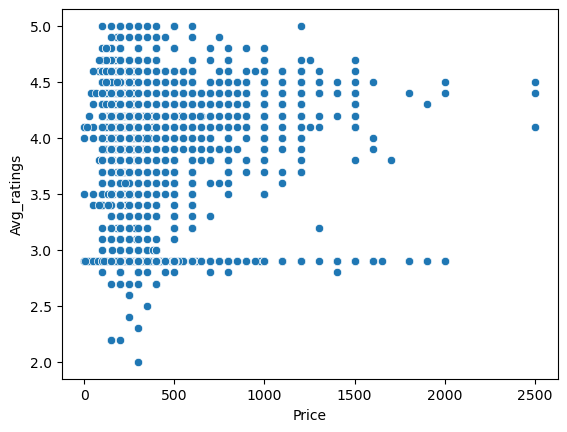

In [46]:
sns.scatterplot(x = 'Price', y = 'Avg_ratings', data = Swiggy)
plt.title = ('Price vs Average Ratings')
plt.xlabel('Price')
plt.ylabel('Avg_ratings')
plt.show()

####  *Clustered Data in Low Price Range
##### Most dots are concentrated between:

##### Price: ₹100 to ₹500

##### Avg_ratings: 3.5 to 4.5
#### *Outliers

##### A few expensive restaurants (Price > ₹1500)
##### Some with very low ratings (below 3.0)
##### These are outliers and could be worth investigating:
##### Why do some high-priced restaurants have low ratings?



<Axes: xlabel='Price', ylabel='Avg_ratings'>

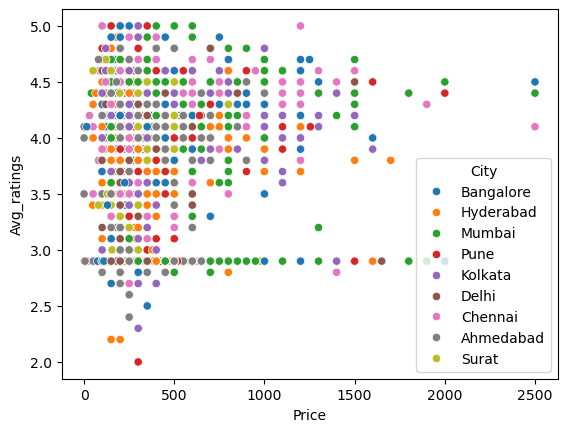

In [45]:
sns.scatterplot(x='Price', y='Avg_ratings', hue='City', data=Swiggy)

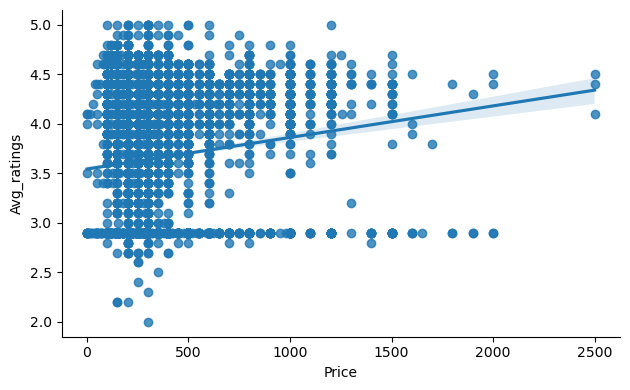

In [66]:
sns.lmplot(x='Price', y='Avg_ratings', data=Swiggy, height=4, aspect=1.6)

#### The upward slope of the line suggests a slight positive correlation: as price increases, ratings tend to increase a little.

##### However, the spread of the dots around the line shows lots of variability, meaning price is not a strong predictor of rating.

##### The shaded area is the confidence interval, showing uncertainty around the trend. A wider band = less confidence.

### Frequency distribution of food items according to price

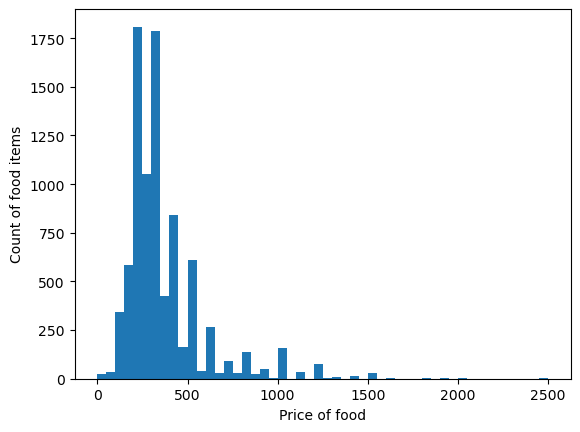

In [48]:
plt.hist(Swiggy.Price, bins=50)
plt.xlabel("Price of food")
plt.ylabel('Count of food items')
plt.show()

#### Above graph shows that maximum food items have their price around 200 to 300.

In [49]:
Swiggy['Delivery_time_group'] = pd.cut(Swiggy['Delivery_time'], bins=5,precision =0,labels=['10-20','20-30','30-40', '40-50', '50-60'])

<Axes: xlabel='Delivery_time', ylabel='Count'>

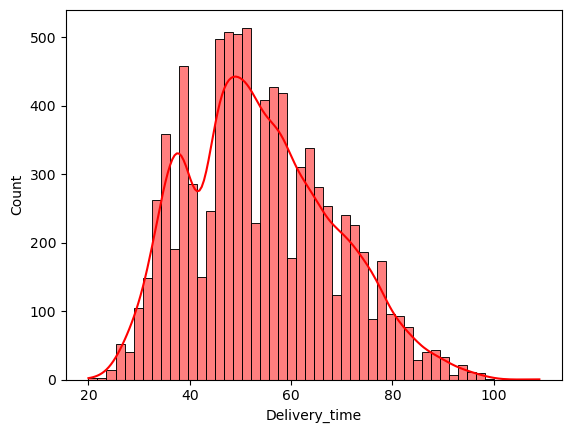

In [50]:
sns.histplot(Swiggy['Delivery_time'], bins=50, kde=True, color='red')

### 1. Most Common Delivery Time (Mode)
The tallest bars and peak of the KDE line occur around 45–50 minutes.

This means:

The most frequent delivery time is around 45 minutes.
### 2. Distribution Shape
The KDE shows a right-skewed distribution (longer tail on the right).

Meaning:

Most deliveries happen in 35–60 minutes, but some take longer, up to 100+ minutes.
### 3. Multi-modality (Two Peaks)
The KDE line has two visible humps (peaks) — one around 35–40 mins and another around 45–50 mins.

This could indicate:

Two types of delivery patterns (e.g., quick-service vs full-service restaurants).

### 4. Outliers
Bars to the far right (e.g., 90–100 mins) are short but present.

These are long delivery times, likely from:

High traffic areas

Distant locations

Inefficient vendors

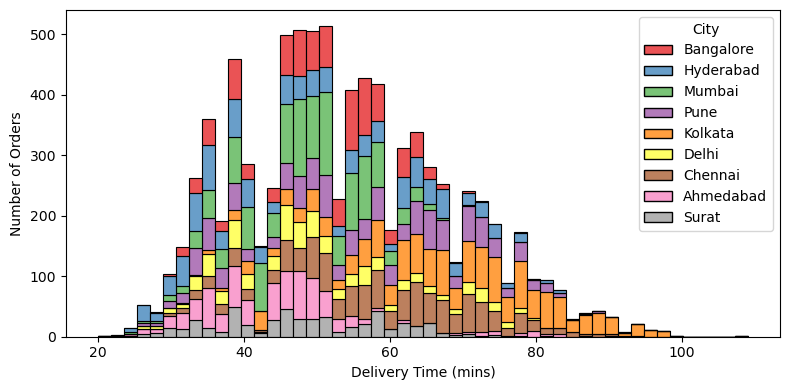

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.histplot(data=Swiggy, x='Delivery_time', hue='City', bins=50, multiple='stack', palette='Set1')

plt.xlabel("Delivery Time (mins)")
plt.ylabel("Number of Orders")
#plt.title('Delivery Time Distribution by City')
plt.tight_layout()
plt.show()


#### Insight Interpretation:

Majority deliveries	35–55 mins across cities

Mumbai & Hyderabad	Fastest & most consistent

Kolkata	Longest delivery tails

Surat & Ahmedabad	Tend to deliver faster

## Observations:
#### Maximum number of restaurants is in Kolkata followed by Mumbai

#### Top 5 restaurants having highest rating:
La Pino'Z Pizza > Nic Natural Ice Creams > Baskin Robbins > Subway > Kfc

#### Bottom 10 restaurants having lowest rating:
Maggi Bowl > Jannath Chicken > Urban Foods Ambawadi > Down Town House > Cia Chinese In Ahmedabad

#### Top 5 Areas having highest rating:
Girish Park > Vardhman Premium Mall > Ekdalia > Santacruz Bandra East > Wallace Garden

#### Top 5 Areas having lowest rating:
Kausar Baugh Nibm Road >  Punjab Bagh > Shakurpur > Dapodi > Dhanakawadi

#### Most frequent ordered prices are 300 and 200.

Indian Food_type was ordered most followed by Chinese having significant difference. Lease ordered Food_type is beverages. Top 5 are Indian > Chinese > North Indian > Fast Food > South Indian

#### Average delivery time is 53.96 min

##### Avg_ratings: 3.5 to 4.5

#### The upward slope of the regression line suggests a slight positive correlation: as price increases, ratings tend to increase a little.

##### However, the spread of the dots around the line shows lots of variability, meaning price is not a strong predictor of rating.

##### The shaded area is the confidence interval, showing uncertainty around the trend. A wider band = less confidence.

#### Above graph shows that maximum food items have their price around 200 to 300.

### 1. Most Common Delivery Time (Mode)
The most frequent delivery time is around 45 minutes.

### 2. Distribution Shape
The KDE shows a right-skewed distribution (longer tail on the right).

Meaning:

Most deliveries happen in 35–60 minutes, but some take longer, up to 100+ minutes.

### 3. Multi-modality (Two Peaks)
The KDE line has two visible humps (peaks) — one around 35–40 mins and another around 45–50 mins.

This could indicate:

Two types of delivery patterns (e.g., quick-service vs full-service restaurants).

### 4. Outliers
Bars to the far right (e.g., 90–100 mins) are short but present.

These are long delivery times, likely from:

High traffic areas

Distant locations

Inefficient vendors


#### Mumbai & Hyderabad	Fastest & most consistent

#### Kolkata	Longest delivery tails

#### Surat & Ahmedabad	Tend to deliver faster